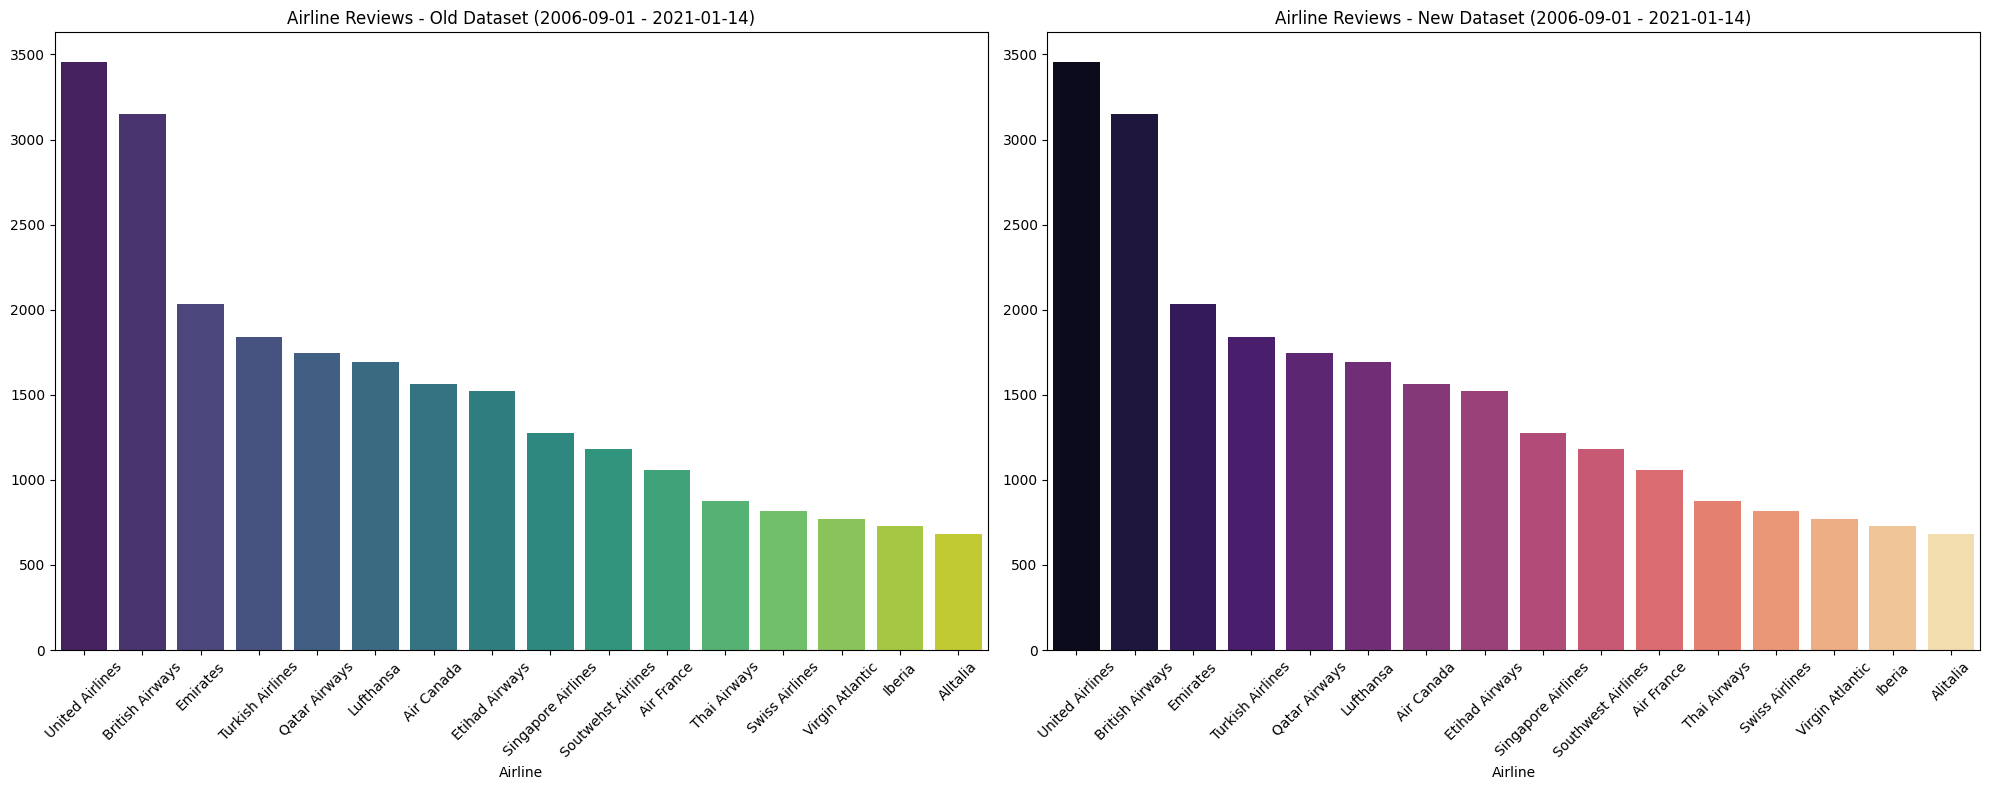

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
airline_new = pd.read_csv('airlinereviews.csv')
airline_old = pd.read_csv('airlinereviews_old.csv')


# Function to process reviews timespan
def process_reviews_timespan(df, date_column):
    # Remove ordinal suffixes (st, nd, rd, th) using regex and convert to datetime
    df[date_column] = pd.to_datetime(df[date_column].str.replace(r'(\d+)(st|nd|rd|th)', r'\1', regex=True))
    
    # Calculate and return the time span
    start_date = df[date_column].min()
    end_date = airline_new[date_column].max()
    return start_date, end_date

start_date_new, end_date_new = process_reviews_timespan(airline_new, 'review_written')
start_date_old, end_date_old = process_reviews_timespan(airline_old, 'review_written')

# Calculate counts for both datasets
old_counts = airline_old['Airline'].value_counts()
new_counts = airline_new['Airline'].value_counts()

# Format timespans for use in titles
old_span = f"({start_date_old.strftime('%Y-%m-%d')} - {end_date_old.strftime('%Y-%m-%d')})"
new_span = f"({start_date_new.strftime('%Y-%m-%d')} - {end_date_new.strftime('%Y-%m-%d')})"
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot Old Dataset
sns.barplot(ax=axes[0], x=old_counts.index, y=old_counts.values, hue=old_counts.index, palette='viridis', legend=False)
axes[0].set_title('Airline Reviews - Old Dataset ' + old_span)
axes[0].tick_params(axis='x', rotation=45)

# Plot New Dataset
sns.barplot(ax=axes[1], x=new_counts.index, y=new_counts.values, hue=new_counts.index, palette='magma', legend=False)
axes[1].set_title('Airline Reviews - New Dataset ' + new_span)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [2]:
airline_new.columns

Index(['Unnamed: 0', 'review_written', 'Airline', 'route', 'overall_rating',
       'title', 'review_text', 'aircraft', 'type_of_traveller', 'seat_type',
       'recommendation'],
      dtype='object')

In [3]:
airline_new.columns

Index(['Unnamed: 0', 'review_written', 'Airline', 'route', 'overall_rating',
       'title', 'review_text', 'aircraft', 'type_of_traveller', 'seat_type',
       'recommendation'],
      dtype='object')

In [4]:
pip install networkx

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Top 10 Routes by Frequency:
         Origin Destination  count
5265     London     Bangkok     38
4916        LHR         BKK     35
964     Bangkok      London     34
690         BKK         LHR     33
5433     London   Singapore     26
5439     London      Sydney     26
8851  Singapore      London     25
8813  Singapore     Bangkok     24
5040        LHR         SIN     24
4278   Istanbul      London     24


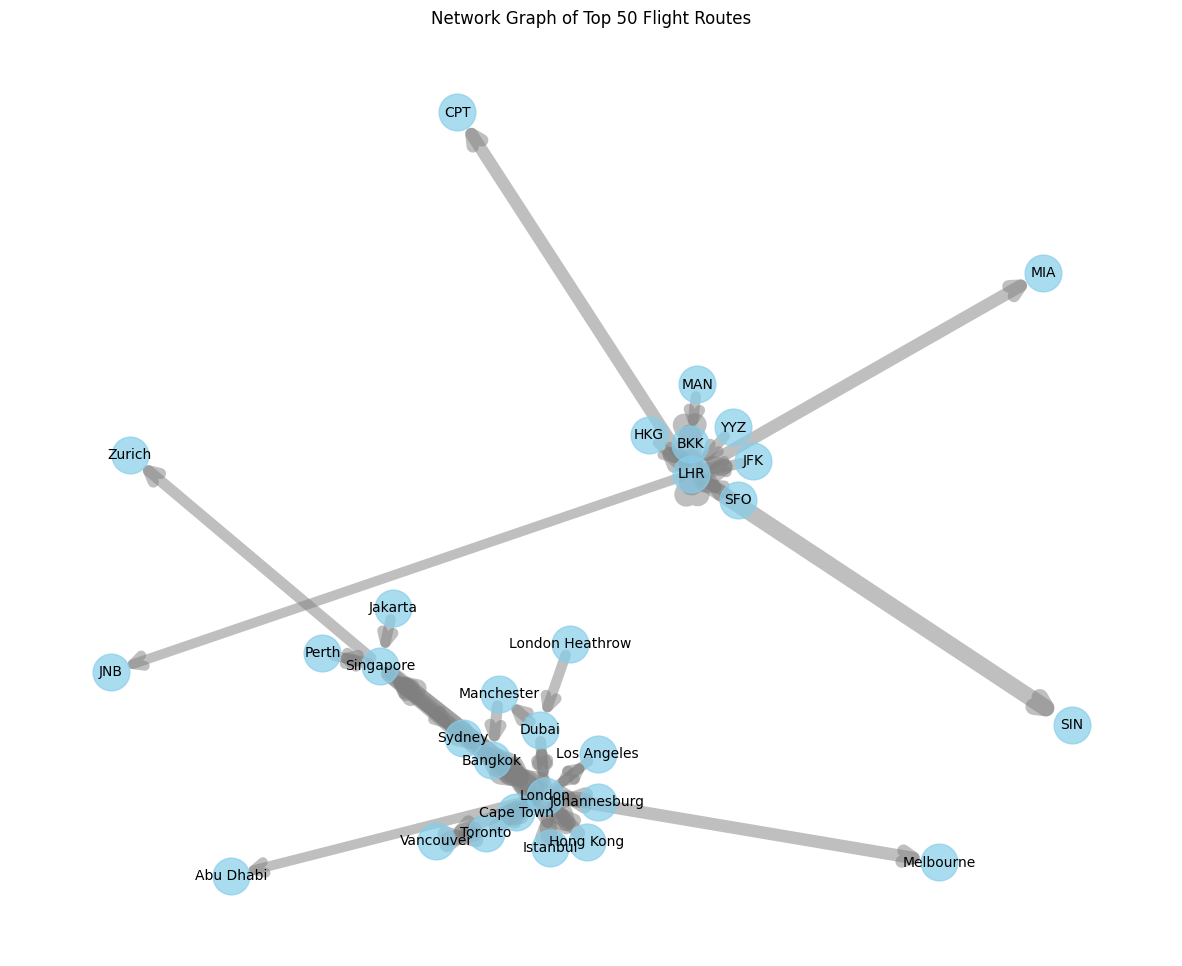

In [10]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt


# 1. Parse Routes from the 'route' column
# The format is typically "Origin to Destination" or "Origin to Destination via Hub"
def parse_route(route_str):
    if pd.isna(route_str):
        return None, None
    
    # Split by " to "
    parts = str(route_str).split(' to ')
    if len(parts) >= 2:
        origin = parts[0].strip()
        # Handle "via" in destination (e.g., "London to Sydney via Singapore")
        dest_part = parts[1].strip()
        if ' via ' in dest_part:
            dest = dest_part.split(' via ')[0].strip()
        else:
            dest = dest_part
        return origin, dest
    return None, None

# Apply parsing to create new columns
airline_new[['Origin', 'Destination']] = airline_new['route'].apply(
    lambda x: pd.Series(parse_route(x))
)

# 2. Calculate Frequencies
# Group by Origin and Destination to count occurrences
route_counts = airline_new.groupby(['Origin', 'Destination']).size().reset_index(name='count')
route_counts = route_counts.dropna()

# Filter for top routes to keep the graph readable (e.g., top 50)
top_routes = route_counts.sort_values('count', ascending=False).head(50)

print("Top 10 Routes by Frequency:")
print(top_routes.head(10))

# 3. Build Network Graph
G = nx.DiGraph() # Directed Graph

for _, row in top_routes.iterrows():
    G.add_edge(row['Origin'], row['Destination'], weight=row['count'])

# 4. Plot
plt.figure(figsize=(15, 12))
# Use spring layout for a naturally spaced graph
pos = nx.spring_layout(G, k=0.5, seed=42) 

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue', alpha=0.7)

# Draw edges with varying width based on frequency
weights = [G[u][v]['weight'] * 0.5 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5, arrowstyle='->', arrowsize=20)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

plt.title('Network Graph of Top 50 Flight Routes')
plt.axis('off')
plt.show()

Handling Missing Data : First lets have an overview of the missing data
There are actually a lot of things we can do in order to handle missing data: 
1) Drop the rows with missing data? Not a very good idea, null aircraft column is roughly 15k rows 
2) Cross fill route and origin-destination pair columns. If one is missing , the other might be able to fill it 
3) Aircraft : Based on the origin and destination, we can fill it with the most common aircraft for that route 
              for that specific airline at that period in time through an external database or dataset 
4) Type of Traveller : Sounds very risky to fill with assumptions , fill it with mean 

In [6]:
airline_new.isnull().sum()

Unnamed: 0               0
review_written           0
Airline                  0
route                 7373
overall_rating         215
title                    0
review_text              0
aircraft             14803
type_of_traveller     7351
seat_type               45
recommendation           0
Origin                7430
Destination           7430
dtype: int64

In [7]:
len(airline_new[
    (airline_new['route'].isna() & airline_new['Origin'].notna() & airline_new['Destination'].notna()) | 
    (airline_new['Origin'].isna() & airline_new['Destination'].isna() & airline_new['route'].notna())
])
# Not very promising , but still filling 57 rows is better than nothing 


57

In [8]:
# Maybe its not that useful to do this , we won't get any useful insights 
ill_route = airline_new[
    (airline_new['route'].isna() & airline_new['Origin'].notna() & airline_new['Destination'].notna())]
fill_origin_dest = airline_new[
    (airline_new['Origin'].isna() & airline_new['Destination'].isna() & airline_new['route'].notna())]

In [9]:
# Filling aircraft column by using pyflightdata 
pip install pyflightdata

SyntaxError: invalid syntax (932953559.py, line 2)

In [11]:
airline_new

,Unnamed: 0,review_written,Airline,route,overall_rating,title,review_text,aircraft,type_of_traveller,seat_type,recommendation,Origin,Destination
0,1,2021-01-07,Air Canada,Washington to Beirut,1.0,"""Very bad service and customer support""",|Very bad service and customer support. They c...,NaN,Solo Leisure,Economy Class,no,Washington,Beirut
1,2,2021-01-05,Air Canada,Toronto to Mumbai,2.0,"""please refund me my money""",|I am messaging with an ardent request to refu...,NaN,Solo Leisure,Economy Class,no,Toronto,Mumbai
2,3,2021-01-05,Air Canada,Vancouver to Toronto via Calgary,6.0,"""The main problem crops up with the IFE in the...","| From a service perspective, Air Canada is gr...",A321,Solo Leisure,Economy Class,yes,Vancouver,Toronto
3,4,2020-12-20,Air Canada,St Lucia to Ottawa via Toronto,1.0,"""this airline is absolutely shameful""","| We returned from St-Lucia yesterday night, D...",NaN,Couple Leisure,Economy Class,no,St Lucia,Ottawa
4,5,2020-12-04,Air Canada,Ottawa to St John's,10.0,"""Air Canada came through""",|My wife and I booked flights through Flight N...,NaN,Couple Leisure,Economy Class,yes,Ottawa,St John's
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386,24387,2013-07-21,Virgin Atlantic,NaN,6.0,Virgin Atlantic customer review,VS200 LHR-SYD in Y+. I was advised at the gate...,NaN,NaN,Premium Economy,yes,None,None
24387,24388,2013-07-17,Virgin Atlantic,NaN,6.0,Virgin Atlantic customer review,Flight VS095 LHR-YVR July 4 2013. Seats 61-63 ...,NaN,NaN,Economy Class,yes,None,None
24388,24389,2013-07-15,Virgin Atlantic,NaN,7.0,Virgin Atlantic customer review,Flown with Virgin Atlantic for the last 13 yea...,NaN,NaN,Premium Economy,no,None,None
24389,24390,2013-07-14,Virgin Atlantic,NaN,2.0,Virgin Atlantic customer review,VS019 from Heathrow to SFO on 7/6/13 we had on...,NaN,NaN,Premium Economy,no,None,None


In [ ]:
#pip install pyflightdata
import pyflightdata as pfd

f = pfd.FlightData()



/Users/fokia/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
pip install airportsdata

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.4/914.4 kB 4.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import airportsdata

# Load the database (indexed by IATA code by default, but we can search it)
airports = airportsdata.load('IATA') 

# Create a reverse lookup dictionary: City Name -> IATA Code
# Note: A city like "London" has multiple airports (LHR, LGW, LCY...). 
# This simple map might just pick one unless we handle it intelligently.
city_to_iata = {}
for code, data in airports.items():
    city = data['city']
    # You might want to prioritize major airports here if duplicates exist
    if city not in city_to_iata:
        city_to_iata[city] = code

def get_iata_from_city(city_name):
    # Basic lookup
    return city_to_iata.get(city_name, None)

# Example Usage
print(get_iata_from_city("London")) 
print(get_iata_from_city("New York"))

YXU
NYS


In [13]:
fill_missing_aircrafts = airline_new[airline_new['aircraft'].isna()] 
    

In [14]:
from pyflightdata import FlightData

f = FlightData()

# If you have credentials (optional but recommended for more data):
# f.login('your_email', 'your_password') 

# Get flight history by flight number (e.g., 'BA123')
# This is usually the best way to get aircraft info for a specific scheduled flight.
history = f.get_history_by_flight_number('BA123')

# The returned data is a list of dictionaries. 
# You can inspect the first item to see the aircraft model.
if history:
    print(history[0]) 
    # Look for 'aircraft' -> 'model' -> 'text' or similar keys in the JSON response

/Users/fokia/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


{'identification': {'number': {'default': 'BA123', 'alternative': 'None'}, 'callsign': 'None', 'codeshare': 'None'}, 'status': {'live': False, 'text': 'Scheduled', 'estimated': 'None', 'ambiguous': False, 'generic': {'status': {'text': 'scheduled', 'type': 'departure', 'color': 'gray', 'diverted': 'None'}, 'eventTime': {'utc': 'None', 'local': 'None'}}}, 'aircraft': {'model': {'code': '789', 'text': 'None'}, 'registration': 'None', 'serialNo': 'None', 'age': 'None', 'restricted': 'None', 'availability': {'serialNo': 'None', 'age': 'None'}}, 'owner': 'None', 'airline': {'name': 'British Airways', 'code': {'iata': 'BA', 'icao': 'BAW'}}, 'airport': {'origin': {'name': 'London Heathrow Airport', 'code': {'iata': 'LHR', 'icao': 'EGLL'}, 'position': {'latitude': 51.471626, 'longitude': -0.467081, 'country': {'name': 'United Kingdom', 'code': 'GB'}, 'region': {'city': 'London'}}, 'timezone': {'name': 'Europe/London', 'offset': 0, 'abbr': 'GMT', 'abbrName': 'Greenwich Mean Time', 'isDst': Fals

In [17]:
import airportsdata
import time
# --- STEP 1: DEFINE CONVERSION LOGIC ---
airports = airportsdata.load('IATA')
# Manual overrides for cities with multiple airports or spelling diffs
city_overrides = {
    'London': 'LHR', 'New York': 'JFK', 'Washington': 'IAD',
    'Toronto': 'YYZ', 'Montreal': 'YUL', 'Vancouver': 'YVR',
    'Beirut': 'BEY', 'Mumbai': 'BOM', 'Delhi': 'DEL',
    'Dubai': 'DXB', "St John's": 'YYT', 'Ottawa': 'YOW'
}
def get_iata_from_city(city_name):
    if not isinstance(city_name, str): return None
    clean_city = city_name.strip()
    # Check overrides first
    if clean_city in city_overrides: return city_overrides[clean_city]
    # Search database
    for code, data in airports.items():
        if data['city'].lower() == clean_city.lower(): return code
    return None
# --- STEP 2: APPLY CONVERSION ---
print("Creating IATA columns...")
# Work on the subset of missing aircrafts
fill_missing_aircrafts = airline_new[airline_new['aircraft'].isna()].copy()
fill_missing_aircrafts['Origin_IATA'] = fill_missing_aircrafts['Origin'].apply(get_iata_from_city)
fill_missing_aircrafts['Destination_IATA'] = fill_missing_aircrafts['Destination'].apply(get_iata_from_city)
print(f"Conversion done. Valid Origins: {fill_missing_aircrafts['Origin_IATA'].notna().sum()}")
# --- STEP 3: QUERY API (With IATA codes) ---
route_aircraft_cache = {}
def fetch_aircraft_info(row):
    # Use the NEW IATA columns
    origin = row['Origin_IATA']
    dest = row['Destination_IATA']
    airline = row['Airline']
    
    if not origin or not dest: return None
        
    cache_key = (origin, dest, airline)
    if cache_key in route_aircraft_cache: return route_aircraft_cache[cache_key]
    
    try:
        print(f"Querying: {origin} -> {dest} ({airline})...")
        # Ensure 'f' is initialized (f = FlightData())
        flights = f.get_flights_from_to(origin, dest)
        
        for flight in flights:
            api_airline = flight.get('airline', {}).get('name', '')
            # Flexible airline matching
            if api_airline and airline.lower() in api_airline.lower():
                aircraft = flight.get('aircraft', {}).get('model', {}).get('text', '')
                if aircraft:
                    route_aircraft_cache[cache_key] = aircraft
                    return aircraft
                    
        route_aircraft_cache[cache_key] = None
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None
    finally:
        time.sleep(1.0) # Respect rate limits
# --- STEP 4: TEST RUN ---
print("\nRunning sample query on first 5 rows...")
sample = fill_missing_aircrafts.copy()
sample['fetched_aircraft'] = sample.apply(fetch_aircraft_info, axis=1)
print(sample[['Origin', 'Origin_IATA', 'Destination', 'Destination_IATA', 'fetched_aircraft']])

Creating IATA columns...
Conversion done. Valid Origins: 5292

Running sample query on first 5 rows...
Querying: IAD -> BEY (Air Canada)...
Querying: YYZ -> BOM (Air Canada)...
Querying: YOW -> YYT (Air Canada)...
Querying: BFI -> YQY (Air Canada)...
Querying: PVG -> FLL (Air Canada)...
Querying: MCC -> BNE (Air Canada)...
Querying: JFK -> YYZ (Air Canada)...
Querying: YUL -> YVR (Air Canada)...
Querying: YVR -> UIO (Air Canada)...
Querying: YEG -> YYZ (Air Canada)...
Querying: DUB -> YEG (Air Canada)...
Querying: PVG -> YVR (Air Canada)...
Querying: JFK -> YYC (Air Canada)...
Querying: YYZ -> BFI (Air Canada)...
Querying: YYZ -> YVR (Air Canada)...
Querying: YOW -> YLW (Air Canada)...
Querying: YEG -> HSH (Air Canada)...
Querying: BEY -> BOS (Air Canada)...
Querying: IND -> MBJ (Air Canada)...
Querying: BOG -> YVR (Air Canada)...
Querying: YYZ -> LHR (Air Canada)...
Querying: JFK -> YUL (Air Canada)...
Querying: YYC -> YHZ (Air Canada)...
Querying: YLW -> YWG (Air Canada)...
Querying:

In [24]:
import time

# 1. Dictionary to cache results: (Origin, Dest, Airline) -> Aircraft Type
# This prevents us from querying the same route 50 times if 50 people flew it.
route_aircraft_cache = {}

def fetch_aircraft_info(row):
    origin = row['Origin_IATA']
    dest = row['Destination_IATA']
    airline = row['Airline']
    
    # Skip if we don't have valid airport codes
    if not origin or not dest:
        return None
        
    # Check cache first
    cache_key = (origin, dest, airline)
    if cache_key in route_aircraft_cache:
        return route_aircraft_cache[cache_key]
    
    try:
        print(f"Querying: {origin} -> {dest} ({airline})...")
        
        # Query pyflightdata (fetches current flights)
        flights = f.get_flights_from_to(origin, dest)
        
        # Loop through found flights to match the airline
        for flight in flights:
            # Flightradar24 data structure usually has 'airline' -> 'name'
            # We do a basic check if our dataset's airline name matches the API's name
            api_airline = flight.get('airline', {}).get('name', '')
            
            if api_airline and airline.lower() in api_airline.lower():
                # Success! Found a match. Extract aircraft model.
                aircraft = flight.get('aircraft', {}).get('model', {}).get('text', '')
                
                if aircraft:
                    # Store in cache and return
                    route_aircraft_cache[cache_key] = aircraft
                    return aircraft
        
        # If we went through all flights and found no match
        route_aircraft_cache[cache_key] = None
        return None
        
    except Exception as e:
        print(f"Error fetching {origin}-{dest}: {e}")
        return None
    finally:
        # Be polite to the API to avoid bans
        time.sleep(1.0) 

# 2. Iterate and fill (Testing on first 10 rows first is a good idea!)
# We use apply() row-by-row (axis=1)
print("Starting API queries... this might take some time.")

# Checking on a small sample first to verify it works
sample_test = fill_missing_aircrafts.copy()
sample_test['fetched_aircraft'] = sample_test.apply(fetch_aircraft_info, axis=1)

# Display result
print("\nSample Results:")
print(sample_test[['Airline', 'Origin', 'Destination', 'fetched_aircraft']])

Starting API queries... this might take some time.
Querying: IAD -> BEY (Air Canada)...
Querying: YYZ -> BOM (Air Canada)...
Querying: YOW -> YYT (Air Canada)...
Querying: BFI -> YQY (Air Canada)...
Querying: PVG -> FLL (Air Canada)...
Querying: MCC -> BNE (Air Canada)...
Querying: JFK -> YYZ (Air Canada)...
Querying: YUL -> YVR (Air Canada)...
Querying: YVR -> UIO (Air Canada)...
Querying: YEG -> YYZ (Air Canada)...
Querying: DUB -> YEG (Air Canada)...
Querying: PVG -> YVR (Air Canada)...
Querying: JFK -> YYC (Air Canada)...
Querying: YYZ -> BFI (Air Canada)...
Querying: YYZ -> YVR (Air Canada)...
Querying: YOW -> YLW (Air Canada)...
Querying: YEG -> HSH (Air Canada)...
Querying: BEY -> BOS (Air Canada)...
Querying: IND -> MBJ (Air Canada)...
Querying: BOG -> YVR (Air Canada)...
Querying: YYZ -> LHR (Air Canada)...
Querying: JFK -> YUL (Air Canada)...
Querying: YYC -> YHZ (Air Canada)...
Querying: YLW -> YWG (Air Canada)...
Querying: LAX -> LHR (Air Canada)...
Querying: YEG -> REO (Ai

In [ ]:
sample_test['fetched_aircraft']

<bound method Series.sum of 0        None
1        None
3        None
4        None
5        None
         ... 
24386    None
24387    None
24388    None
24389    None
24390    None
Name: fetched_aircraft, Length: 14803, dtype: object>

In [35]:
sample_test.to_csv("sample_test.csv") #Added entries from api

In [30]:
# 1. Update the main DataFrame using the index alignment
# This finds rows in 'airline_new' that match the index of your result and updates them.
# The 'fetched_aircraft' column must be renamed to target 'aircraft'.

# Assuming 'sample_test' is the dataframe with the results
# If you ran it on 'fill_missing_aircrafts', change the variable name below.
source_df = sample_test # Change this to fill_missing_aircrafts when ready for full run

# Perform the update
airline_new.update(source_df['fetched_aircraft'].rename('aircraft'))

# 2. Verify the update
updated_indices = source_df.index
print("Updated Rows:")
print(airline_new.loc[updated_indices, ['Airline', 'Origin', 'Destination', 'aircraft']])

# Check total missing count
print(f"\nRemaining missing aircraft values: {airline_new['aircraft'].isna().sum()}")

Updated Rows:
               Airline      Origin Destination aircraft
0           Air Canada  Washington      Beirut      NaN
1           Air Canada     Toronto      Mumbai      NaN
3           Air Canada    St Lucia      Ottawa      NaN
4           Air Canada      Ottawa   St John's      NaN
5           Air Canada     Seattle      Sydney      NaN
...                ...         ...         ...      ...
24386  Virgin Atlantic        None        None      NaN
24387  Virgin Atlantic        None        None      NaN
24388  Virgin Atlantic        None        None      NaN
24389  Virgin Atlantic        None        None      NaN
24390  Virgin Atlantic        None        None      NaN

[14803 rows x 4 columns]

Remaining missing aircraft values: 14299


In [31]:
airline_new 

,Unnamed: 0,review_written,Airline,route,overall_rating,title,review_text,aircraft,type_of_traveller,seat_type,recommendation,Origin,Destination
0,1,2021-01-07,Air Canada,Washington to Beirut,1.0,"""Very bad service and customer support""",|Very bad service and customer support. They c...,NaN,Solo Leisure,Economy Class,no,Washington,Beirut
1,2,2021-01-05,Air Canada,Toronto to Mumbai,2.0,"""please refund me my money""",|I am messaging with an ardent request to refu...,NaN,Solo Leisure,Economy Class,no,Toronto,Mumbai
2,3,2021-01-05,Air Canada,Vancouver to Toronto via Calgary,6.0,"""The main problem crops up with the IFE in the...","| From a service perspective, Air Canada is gr...",A321,Solo Leisure,Economy Class,yes,Vancouver,Toronto
3,4,2020-12-20,Air Canada,St Lucia to Ottawa via Toronto,1.0,"""this airline is absolutely shameful""","| We returned from St-Lucia yesterday night, D...",NaN,Couple Leisure,Economy Class,no,St Lucia,Ottawa
4,5,2020-12-04,Air Canada,Ottawa to St John's,10.0,"""Air Canada came through""",|My wife and I booked flights through Flight N...,NaN,Couple Leisure,Economy Class,yes,Ottawa,St John's
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386,24387,2013-07-21,Virgin Atlantic,NaN,6.0,Virgin Atlantic customer review,VS200 LHR-SYD in Y+. I was advised at the gate...,NaN,NaN,Premium Economy,yes,None,None
24387,24388,2013-07-17,Virgin Atlantic,NaN,6.0,Virgin Atlantic customer review,Flight VS095 LHR-YVR July 4 2013. Seats 61-63 ...,NaN,NaN,Economy Class,yes,None,None
24388,24389,2013-07-15,Virgin Atlantic,NaN,7.0,Virgin Atlantic customer review,Flown with Virgin Atlantic for the last 13 yea...,NaN,NaN,Premium Economy,no,None,None
24389,24390,2013-07-14,Virgin Atlantic,NaN,2.0,Virgin Atlantic customer review,VS019 from Heathrow to SFO on 7/6/13 we had on...,NaN,NaN,Premium Economy,no,None,None


/var/folders/ss/xj7vz6w928x9h7yd27w3_6_w0000gn/T/ipykernel_53268/4025695422.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airline_means, x='Airline', y='overall_rating', palette='viridis')


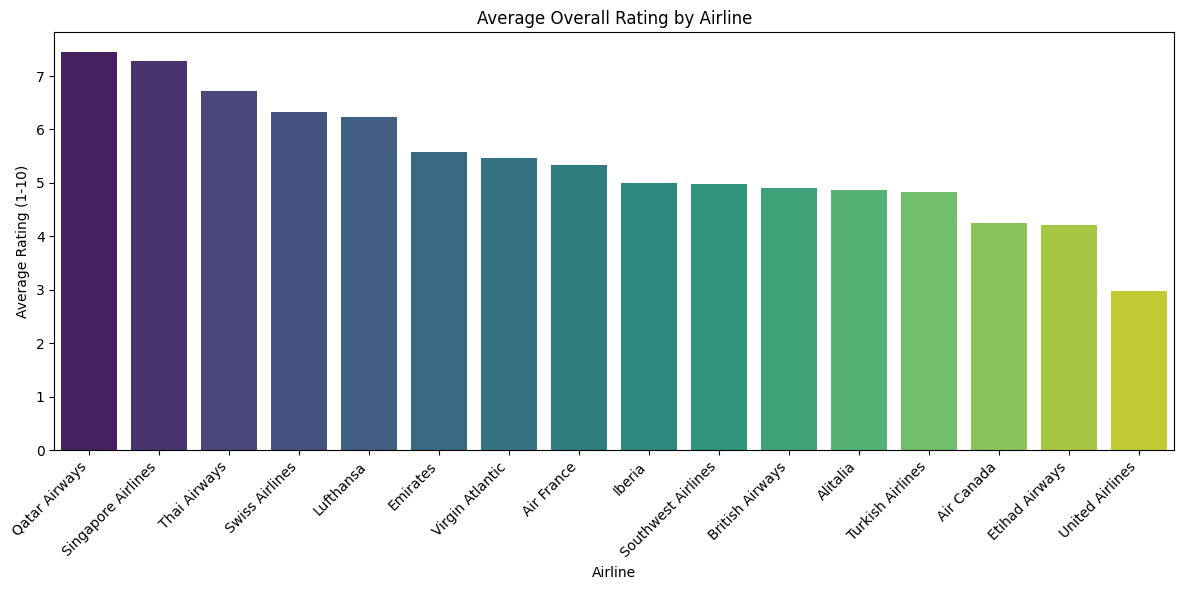

/var/folders/ss/xj7vz6w928x9h7yd27w3_6_w0000gn/T/ipykernel_53268/4025695422.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aircraft_means, x='aircraft', y='overall_rating', palette='magma')


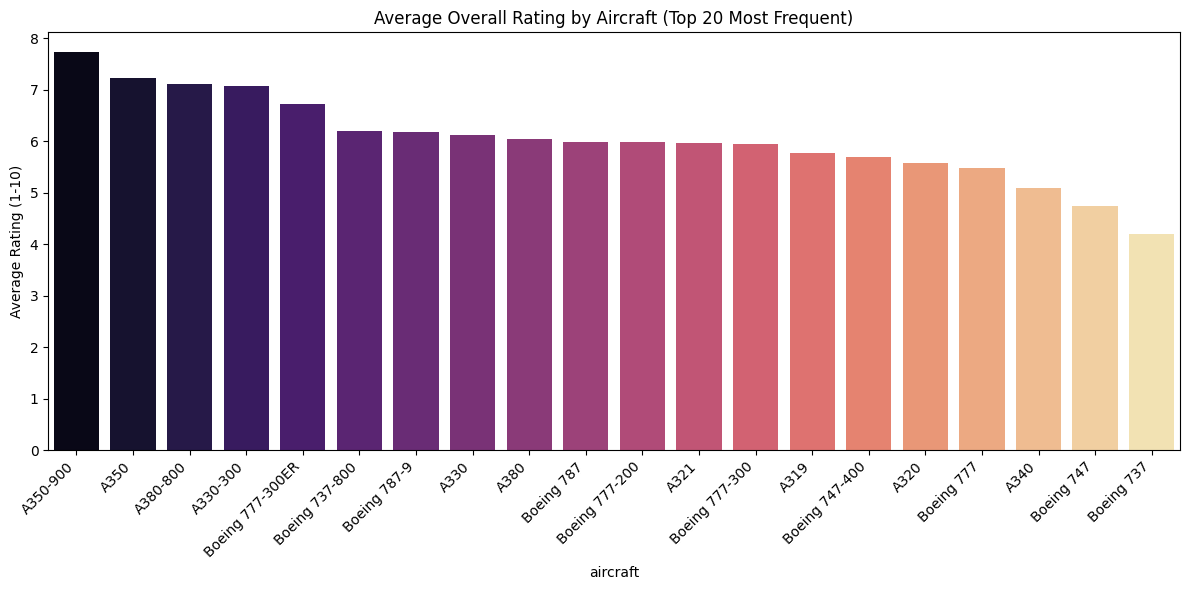

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- FIGURE 1: Average Rating by Airline ---
# Calculate means
airline_means = airline_new.groupby('Airline')['overall_rating'].mean().reset_index()
airline_means = airline_means.sort_values('overall_rating', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=airline_means, x='Airline', y='overall_rating', palette='viridis')
plt.title('Average Overall Rating by Airline')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Rating (1-10)')
plt.tight_layout()
plt.show()

# --- FIGURE 2: Average Rating by Aircraft ---
# Filter for top 20 most frequent aircraft to avoid clutter
top_aircraft = airline_new['aircraft'].value_counts().head(20).index
aircraft_subset = airline_new[airline_new['aircraft'].isin(top_aircraft)]

# Calculate means for the subset
aircraft_means = aircraft_subset.groupby('aircraft')['overall_rating'].mean().reset_index()
aircraft_means = aircraft_means.sort_values('overall_rating', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=aircraft_means, x='aircraft', y='overall_rating', palette='magma')
plt.title('Average Overall Rating by Aircraft (Top 20 Most Frequent)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Rating (1-10)')
plt.tight_layout()
plt.show()

/var/folders/ss/xj7vz6w928x9h7yd27w3_6_w0000gn/T/ipykernel_53268/3383510759.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_airlines, x='Airline', y='overall_rating', palette='Reds_r', ax=axes[0])
/var/folders/ss/xj7vz6w928x9h7yd27w3_6_w0000gn/T/ipykernel_53268/3383510759.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_aircraft, x='aircraft', y='overall_rating', palette='Reds_r', ax=axes[1])


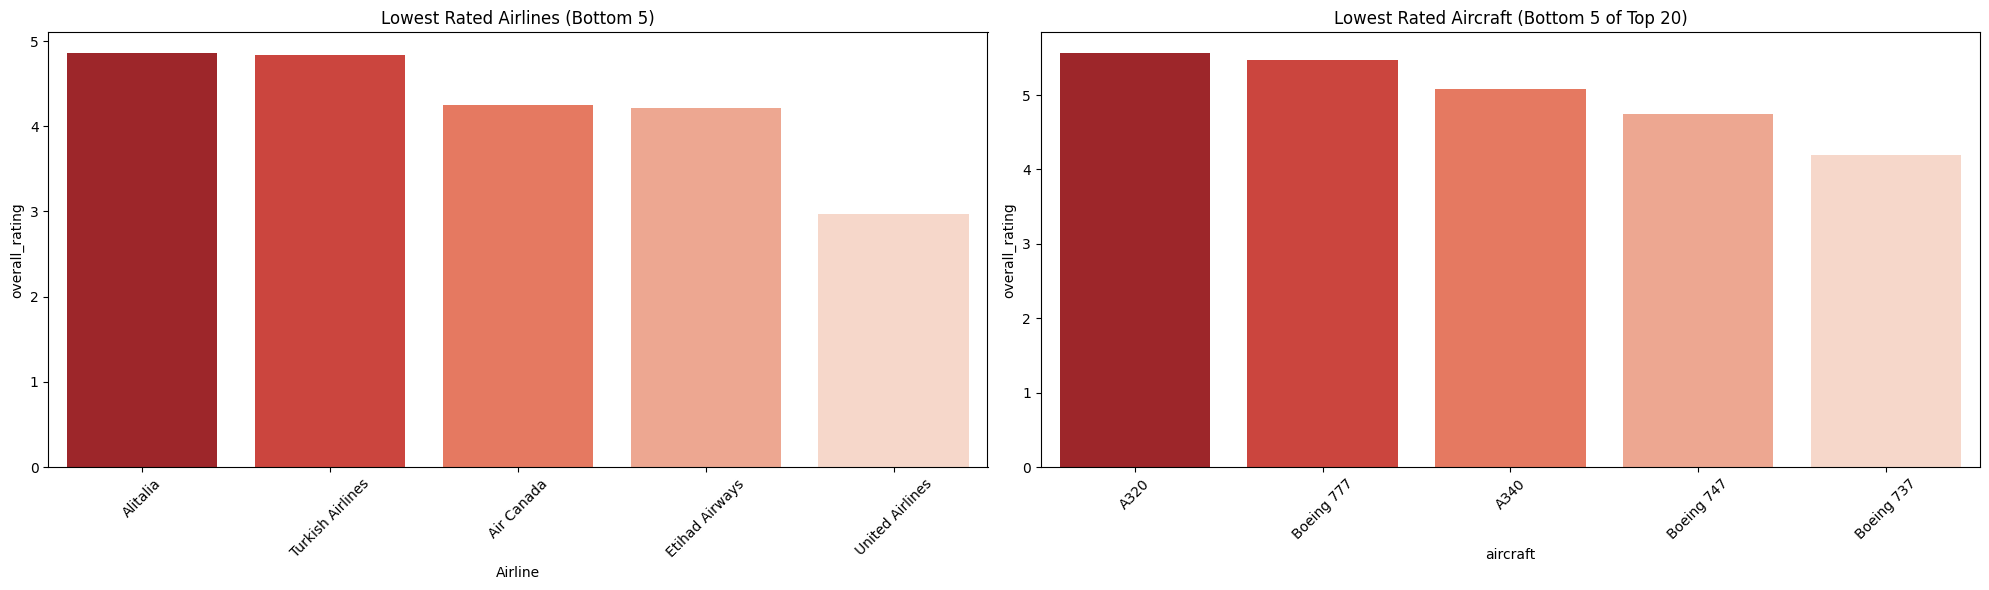

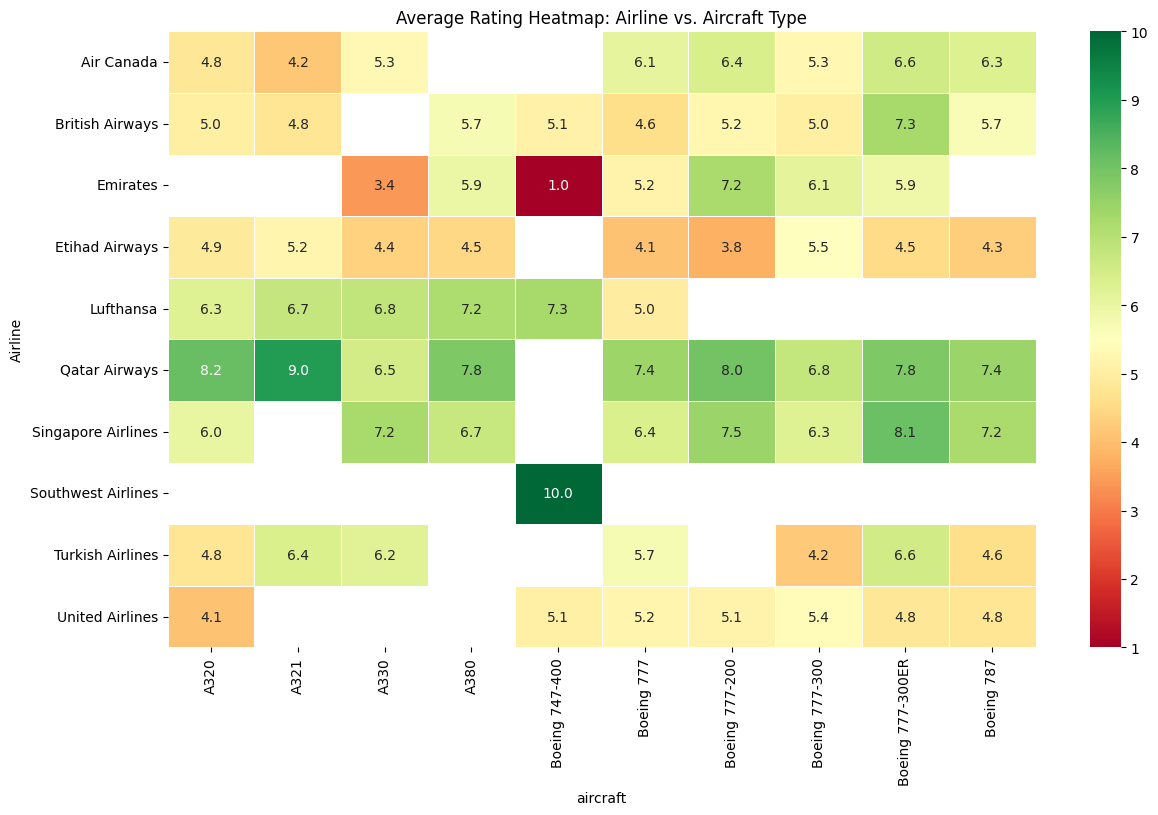

In [34]:
# --- FIGURE 3: Worst Performers (Bottom 5) ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Worst 5 Airlines
worst_airlines = airline_means.tail(5)
sns.barplot(data=worst_airlines, x='Airline', y='overall_rating', palette='Reds_r', ax=axes[0])
axes[0].set_title('Lowest Rated Airlines (Bottom 5)')
axes[0].tick_params(axis='x', rotation=45)

# Worst 5 Aircraft (from top 20 most frequent to ensure data sufficiency)
worst_aircraft = aircraft_means.tail(5)
sns.barplot(data=worst_aircraft, x='aircraft', y='overall_rating', palette='Reds_r', ax=axes[1])
axes[1].set_title('Lowest Rated Aircraft (Bottom 5 of Top 20)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- FIGURE 4: Airline vs. Aircraft Correlation Heatmap ---
# Filter data to only include the Top 10 Airlines and Top 10 Aircraft
# This ensures we have enough data points for the heatmap to be meaningful.
top_10_airlines = airline_new['Airline'].value_counts().head(10).index
top_10_aircraft = airline_new['aircraft'].value_counts().head(10).index

heatmap_data = airline_new[
    (airline_new['Airline'].isin(top_10_airlines)) & 
    (airline_new['aircraft'].isin(top_10_aircraft))
]

# Create Pivot Table: Rows=Airline, Cols=Aircraft, Values=Rating
pivot_metrics = heatmap_data.pivot_table(
    index='Airline', 
    columns='aircraft', 
    values='overall_rating', 
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_metrics, annot=True, cmap='RdYlGn', fmt='.1f', linewidths=.5)
plt.title('Average Rating Heatmap: Airline vs. Aircraft Type')
plt.show()

In [32]:
# --- ROBUSTNESS CHECK: Review Lengths ---

# 1. Calculate word counts (handling NaNs)
airline_new['word_count'] = airline_new['review_text'].fillna('').apply(lambda x: len(str(x).split()))

# 2. Determine outliers (Top/Bottom 5%)
lower_bound = airline_new['word_count'].quantile(0.05)
upper_bound = airline_new['word_count'].quantile(0.95)

print(f"Filtering reviews: Keep length between {lower_bound:.0f} and {upper_bound:.0f} words.")

# 3. Create filtered dataset
robust_df = airline_new[
    (airline_new['word_count'] >= lower_bound) & 
    (airline_new['word_count'] <= upper_bound)
].copy()

# 4. Compare Metrics (e.g. Average Rating)
# Group by Airline and calculate mean rating
original_ratings = airline_new.groupby('Airline')['overall_rating'].mean().rename("Original_Rating")
robust_ratings = robust_df.groupby('Airline')['overall_rating'].mean().rename("Robust_Rating")

# Combine and check difference
comparison = pd.concat([original_ratings, robust_ratings], axis=1)
comparison['Diff'] = comparison['Original_Rating'] - comparison['Robust_Rating']
comparison['Rank_Change'] = comparison['Original_Rating'].rank(ascending=False) - comparison['Robust_Rating'].rank(ascending=False)

# Show comparison for top airlines
print("\nTop Airlines Rating Comparison:")
print(comparison.sort_values(by='Original_Rating', ascending=False).head(10))

# Conclusion check
max_diff = comparison['Diff'].abs().max()
print(f"\nMax Rating Fluctuation: {max_diff:.4f}")

if max_diff < 0.5:
    print("CONCLUSION: Robust. Results do not significantly change when removing extreme reviews.")
else:
    print("CONCLUSION: Sensitive. Removing outliers significantly affects ratings.")

Filtering reviews: Keep length between 43 and 346 words.

Top Airlines Rating Comparison:
                    Original_Rating  Robust_Rating      Diff  Rank_Change
Airline                                                                  
Qatar Airways              7.445907       7.383019  0.062888          0.0
Singapore Airlines         7.277778       7.268335  0.009443          0.0
Thai Airways               6.717714       6.634981  0.082733          0.0
Swiss Airlines             6.324969       6.336054 -0.011086          0.0
Lufthansa                  6.236718       6.239446 -0.002728          0.0
Emirates                   5.580296       5.659946 -0.079650          0.0
Virgin Atlantic            5.472042       5.438122  0.033919          0.0
Air France                 5.325779       5.295099  0.030680          0.0
Iberia                     5.001531       5.008432 -0.006900         -1.0
Southwest Airlines         4.985740       5.065239 -0.079499          1.0

Max Rating Fluctuatio